# Vision Transformer для классификации фруктов и овощей

Цирулев НВ М8О-408Б-22

## 1. Выбор начальных условий

Фиксируем задачу многоклассовой классификации фруктов и овощей, путь к датасету, устройство обучения и основные гиперпараметры transformer-экспериментов. Для `torchvision` ViT было принято решение использовать transfer learning, так как обучение ViT с нуля на малом датасете дает низкое качество.

Подключаем библиотеки и локальные модули проекта, фиксируем параметры эксперимента и загружаем датасет через Kaggle API, если он еще не находится в `data/`.

In [ ]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fruitveg_lab.data import create_dataloaders, describe_dataset, ensure_kaggle_dataset, make_transforms
from fruitveg_lab.models import (
    TinyVisionTransformer,
    configure_vit_finetuning,
    count_trainable_parameters,
    create_torchvision_vit,
)
from fruitveg_lab.plotting import plot_confusion_matrix, plot_history, show_image_grid
from fruitveg_lab.training import RunConfig, fit_classifier, get_device, make_conclusion, print_report, seed_everything, summarize_results

FAST_DEV_RUN = False
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2
BASE_EPOCHS = 5
SEED = 42

DATA_DIR = PROJECT_ROOT / "data" / "fruit-and-vegetable-image-recognition"
DATA_ROOT = ensure_kaggle_dataset(DATA_DIR)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "transformer"
DEVICE = get_device()

warnings.filterwarnings(
    "ignore",
    message="Palette images with Transparency expressed in bytes should be converted to RGBA images",
    category=UserWarning,
    module="PIL.Image",
)

seed_everything(SEED)
print(f"project: {PROJECT_ROOT}")
print(f"dataset: {DATA_ROOT}")
print(f"device: {DEVICE}")

### 1.a. Набор данных и практическая задача

Датасет используется для распознавания продукта по фотографии. Практический смысл: кассы самообслуживания, складской учет, приложения питания и автоматическая маркировка товаров.

Проверяем структуру датасета и формируем таблицу количества изображений по классам в `train`, `validation` и `test`.

In [2]:
info = describe_dataset(DATA_ROOT)
counts = pd.DataFrame(info.split_counts).fillna(0).astype(int)
counts["total"] = counts.sum(axis=1)
display(counts)
print(f"classes: {len(info.classes)}")
print(f"train images: {counts['train'].sum()}")
print(f"validation images: {counts['validation'].sum()}")
print(f"test images: {counts['test'].sum()}")

,train,validation,test,total
apple,68,10,10,88
banana,75,9,9,93
beetroot,88,10,10,108
bell pepper,90,9,10,109
cabbage,92,10,10,112
capsicum,89,10,10,109
carrot,82,9,10,101
cauliflower,79,10,10,99
chilli pepper,87,9,10,106
corn,87,10,10,107


classes: 36
train images: 3115
validation images: 351
test images: 359


### 1.b. Метрики качества

Основные метрики: `accuracy`, macro/weighted `precision`, `recall`, `F1`, `top-3 accuracy`, classification report и confusion matrix. Для выбора лучшей конфигурации используется `validation macro F1`, потому что все классы важны одинаково.

Создаем DataLoader-объекты для выбранного режима преобразований и визуализируем примеры обучающих изображений.

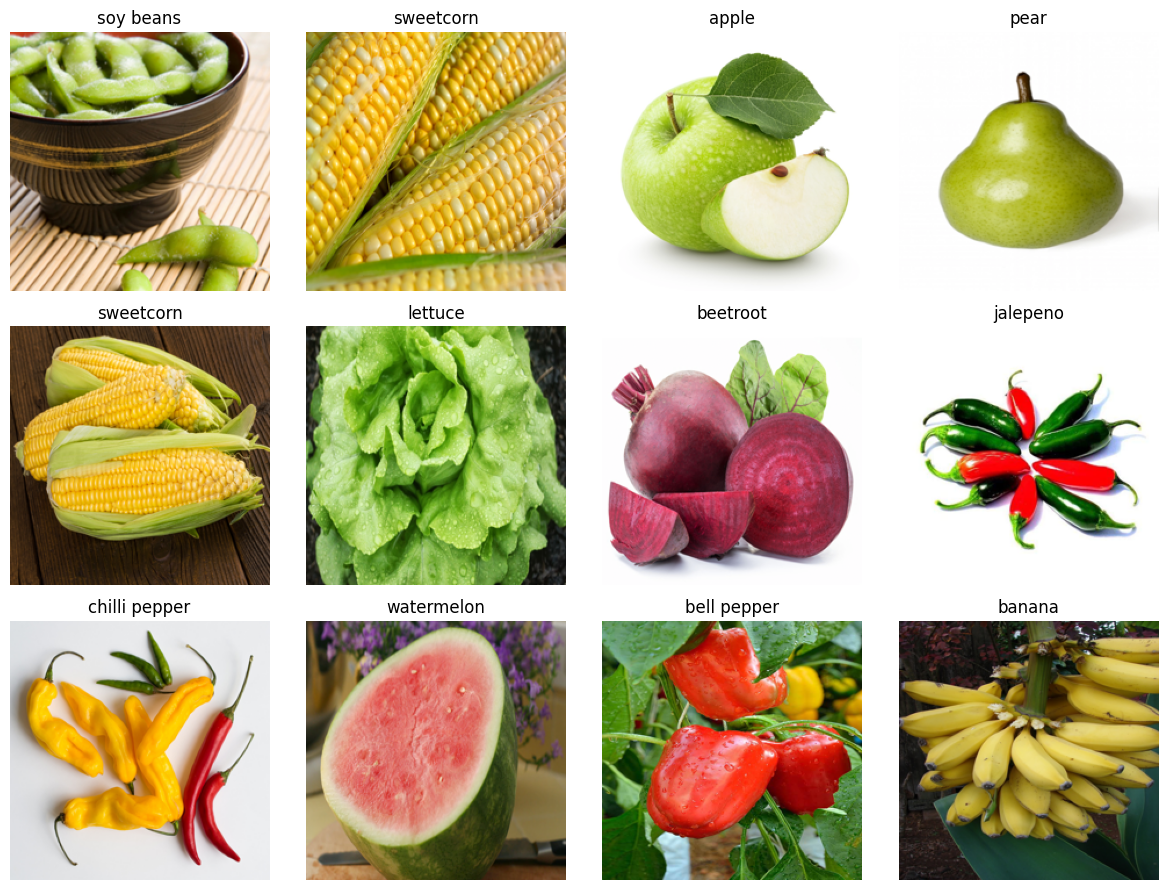

In [3]:
def loaders_for(transform_mode: str, batch_size: int = BATCH_SIZE):
    train_transform = make_transforms(IMAGE_SIZE, mode=transform_mode, normalize=True)
    eval_transform = make_transforms(IMAGE_SIZE, mode="plain", normalize=True)
    return create_dataloaders(
        DATA_ROOT,
        train_transform=train_transform,
        eval_transform=eval_transform,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
    )

preview_loaders = loaders_for("plain", batch_size=12)
show_image_grid(preview_loaders.train, preview_loaders.class_names, count=12, normalized=True)

## 2. Создание бейзлайна и оценка качества

Пункты 2.a-2.b: обучаем transformer baseline `ViT-B/16` из `torchvision` с ImageNet-весами. На baseline-этапе замораживаем backbone и обучаем только классификационную голову на 36 классов.

Обучаем baseline `torchvision ViT-B/16` в режиме feature extraction: используем ImageNet-веса, замораживаем backbone, обучаем classifier head и оцениваем качество на test split.

trainable parameters: 27,684 / 85,826,340

torchvision_vit_b16_imagenet_head: training on cuda


epoch 01/5: train_loss=1.1936, train_acc=0.7136, val_loss=0.4266, val_macro_f1=0.8718


epoch 02/5: train_loss=0.4722, train_acc=0.8600, val_loss=0.2879, val_macro_f1=0.9166


epoch 03/5: train_loss=0.3360, train_acc=0.9030, val_loss=0.2459, val_macro_f1=0.9237


epoch 04/5: train_loss=0.2638, train_acc=0.9230, val_loss=0.2345, val_macro_f1=0.9170


epoch 05/5: train_loss=0.2135, train_acc=0.9400, val_loss=0.1960, val_macro_f1=0.9487


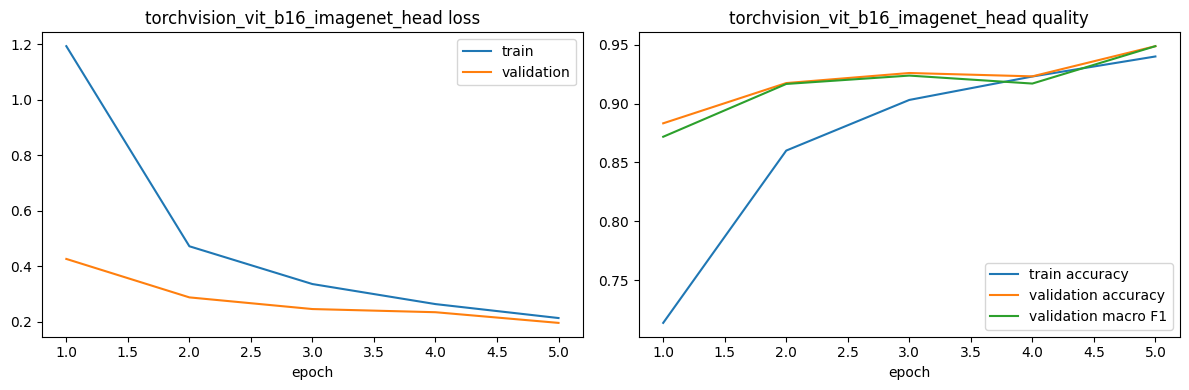

torchvision_vit_b16_imagenet_head | test classification report
               precision    recall  f1-score   support

        apple       1.00      0.80      0.89        10
       banana       1.00      0.89      0.94         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.80      0.80      0.80        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.69      0.90      0.78        10
       carrot       0.90      0.90      0.90        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       1.00      0.90      0.95        10
         corn       0.78      0.70      0.74        10
     cucumber       1.00      1.00      1.00        10
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       ginger       1.00      1.00      1.00        10
       grapes       1.00      1.00      1.00        10
     jalepeno       0.83      1.00      0.91        10
 

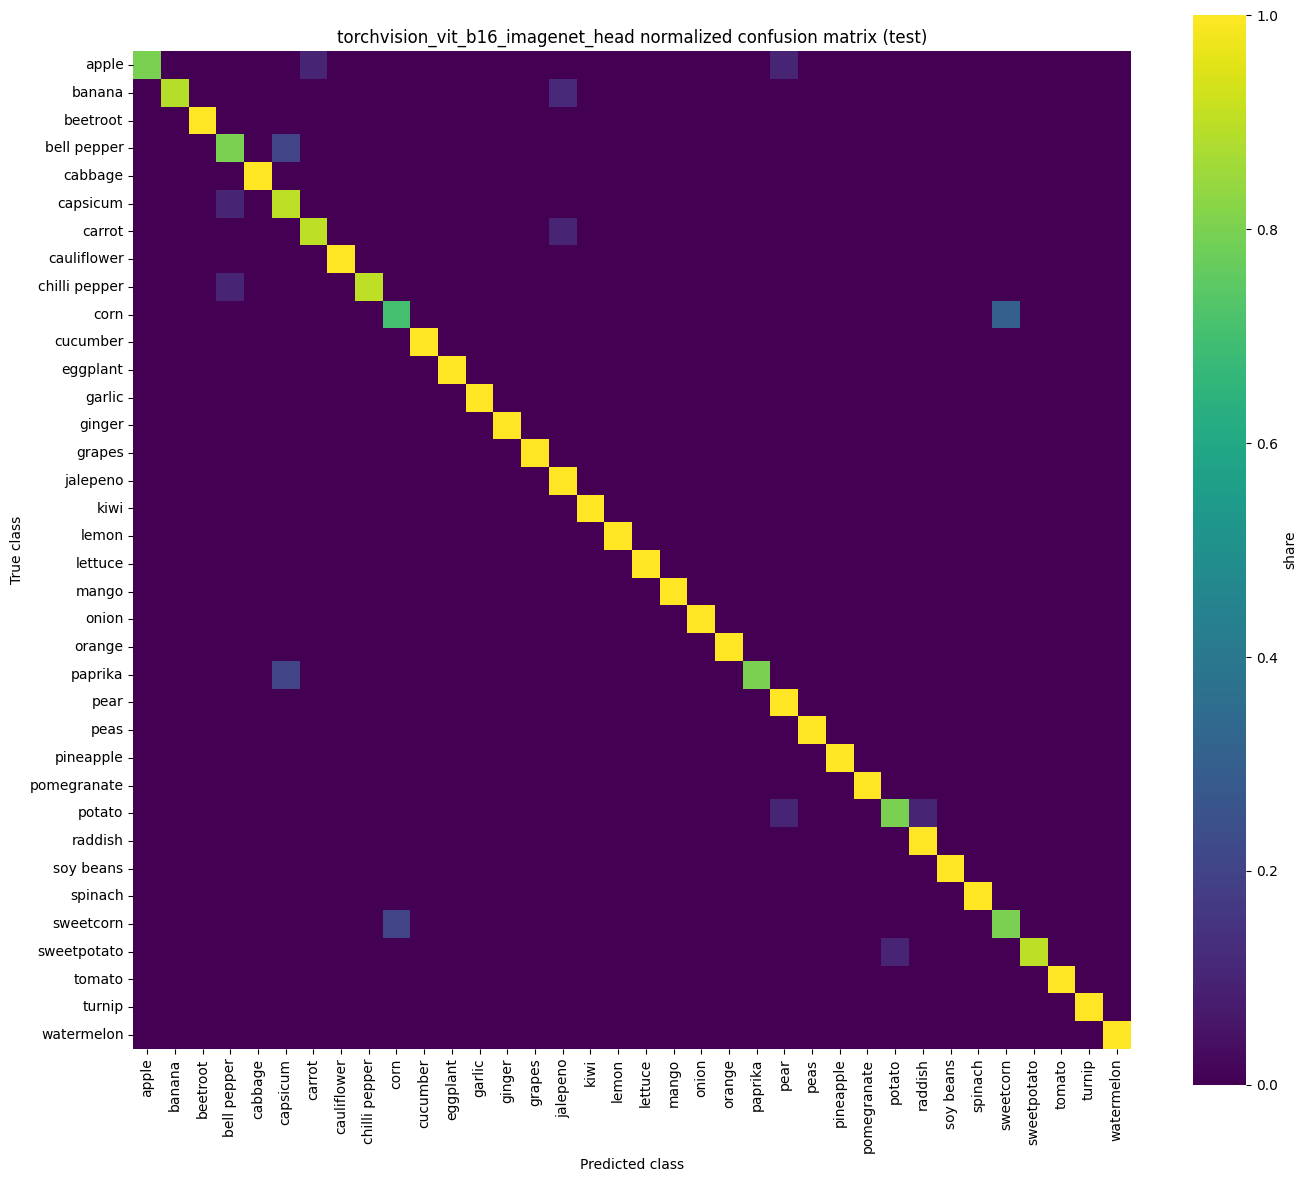

In [4]:
num_classes = len(preview_loaders.class_names)
plain_loaders = loaders_for("plain")

baseline_model = create_torchvision_vit(
    "vit_b_16",
    num_classes=num_classes,
    image_size=IMAGE_SIZE,
    weights="imagenet",
)
baseline_model = configure_vit_finetuning(baseline_model, mode="head")
trainable, total = count_trainable_parameters(baseline_model)
print(f"trainable parameters: {trainable:,} / {total:,}")

vit_baseline = fit_classifier(
    baseline_model,
    name="torchvision_vit_b16_imagenet_head",
    train_loader=plain_loaders.train,
    val_loader=plain_loaders.val,
    test_loader=plain_loaders.test,
    class_names=plain_loaders.class_names,
    config=RunConfig(
        epochs=BASE_EPOCHS,
        learning_rate=1e-3,
        weight_decay=1e-4,
        scheduler="none",
        fast_dev_run=FAST_DEV_RUN,
        seed=SEED,
    ),
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

plot_history(vit_baseline)
print_report(vit_baseline)
plot_confusion_matrix(vit_baseline)

## 3. Улучшение бейзлайна

Пункты 3.a-3.g: формулируем и проверяем гипотезы про аугментации, cosine scheduler, разморозку последних encoder-блоков и `ViT-B/32`; лучшую конфигурацию выбираем по `validation macro F1` и сравниваем с baseline.

Проводим серию transformer-экспериментов с предобученными весами, разными режимами fine-tuning и аугментациями, затем формируем таблицы для validation и test split.

In [5]:
vit_specs = [
    {
        "name": "vit_b16_imagenet_head_augmented",
        "model": "vit_b_16",
        "weights": "imagenet",
        "tuning_mode": "head",
        "trainable_blocks": 0,
        "transform_mode": "augmented",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "cosine",
        "epochs": BASE_EPOCHS,
    },
    {
        "name": "vit_b16_imagenet_last2",
        "model": "vit_b_16",
        "weights": "imagenet",
        "tuning_mode": "last_blocks",
        "trainable_blocks": 2,
        "transform_mode": "plain",
        "learning_rate": 2e-5,
        "weight_decay": 1e-4,
        "scheduler": "cosine",
        "epochs": BASE_EPOCHS + 2,
    },
    {
        "name": "vit_b16_imagenet_last4_augmented",
        "model": "vit_b_16",
        "weights": "imagenet",
        "tuning_mode": "last_blocks",
        "trainable_blocks": 4,
        "transform_mode": "augmented",
        "learning_rate": 1e-5,
        "weight_decay": 2e-4,
        "scheduler": "cosine",
        "epochs": BASE_EPOCHS + 2,
    },
    {
        "name": "vit_b32_imagenet_head_augmented",
        "model": "vit_b_32",
        "weights": "imagenet",
        "tuning_mode": "head",
        "trainable_blocks": 0,
        "transform_mode": "augmented",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "cosine",
        "epochs": BASE_EPOCHS,
    },
]

vit_experiment_records = []
for spec in vit_specs:
    loaders = loaders_for(spec["transform_mode"])
    model = create_torchvision_vit(
        spec["model"],
        num_classes=num_classes,
        image_size=IMAGE_SIZE,
        weights=spec["weights"],
    )
    model = configure_vit_finetuning(
        model,
        mode=spec["tuning_mode"],
        trainable_blocks=spec["trainable_blocks"],
    )
    trainable, total = count_trainable_parameters(model)
    print(f"{spec['name']}: trainable parameters {trainable:,} / {total:,}")

    result = fit_classifier(
        model,
        name=spec["name"],
        train_loader=loaders.train,
        val_loader=loaders.val,
        test_loader=loaders.test,
        class_names=loaders.class_names,
        config=RunConfig(
            epochs=spec["epochs"],
            learning_rate=spec["learning_rate"],
            weight_decay=spec["weight_decay"],
            scheduler=spec["scheduler"],
            fast_dev_run=FAST_DEV_RUN,
            seed=SEED,
        ),
        device=DEVICE,
        output_dir=OUTPUT_DIR,
    )
    vit_experiment_records.append({"spec": spec, "result": result})

vit_hypothesis_results = [record["result"] for record in vit_experiment_records]
display(summarize_results([vit_baseline] + vit_hypothesis_results, split="val"))
display(summarize_results([vit_baseline] + vit_hypothesis_results, split="test"))

vit_b16_imagenet_head_augmented: trainable parameters 27,684 / 85,826,340

vit_b16_imagenet_head_augmented: training on cuda


epoch 01/5: train_loss=1.1949, train_acc=0.7130, val_loss=0.4632, val_macro_f1=0.8496


epoch 02/5: train_loss=0.4930, train_acc=0.8523, val_loss=0.3212, val_macro_f1=0.9073


epoch 03/5: train_loss=0.3769, train_acc=0.8883, val_loss=0.2896, val_macro_f1=0.9098


epoch 04/5: train_loss=0.3219, train_acc=0.9079, val_loss=0.2765, val_macro_f1=0.9073


...

epoch 03/5: train_loss=0.4550, train_acc=0.8658, val_loss=0.3242, val_macro_f1=0.9121


epoch 04/5: train_loss=0.3818, train_acc=0.8886, val_loss=0.3047, val_macro_f1=0.9084


epoch 05/5: train_loss=0.3478, train_acc=0.9056, val_loss=0.2959, val_macro_f1=0.9168


,model,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top3_accuracy
0,torchvision_vit_b16_imagenet_head,5,0.948718,0.952901,0.948457,0.948725,0.949130,0.980057
1,vit_b16_imagenet_last2,6,0.940171,0.945426,0.940432,0.938700,0.939131,0.982906
2,vit_b16_imagenet_last4_augmented,6,0.923077,0.938305,0.923148,0.919678,0.920156,0.985755
3,vit_b32_imagenet_head_augmented,5,0.917379,0.930973,0.917284,0.916783,0.917756,0.977208
4,vit_b16_imagenet_head_augmented,3,0.911681,0.923559,0.912037,0.909829,0.910506,0.982906


,model,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top3_accuracy
0,torchvision_vit_b16_imagenet_head,5,0.949861,0.954500,0.949691,0.950214,0.950239,0.980501
1,vit_b16_imagenet_last2,6,0.941504,0.947325,0.941049,0.940115,0.940296,0.983287
2,vit_b16_imagenet_last4_augmented,6,0.924791,0.940438,0.924383,0.921545,0.921675,0.986072
3,vit_b32_imagenet_head_augmented,5,0.913649,0.927600,0.913272,0.913409,0.913516,0.977716
4,vit_b16_imagenet_head_augmented,3,0.913649,0.926035,0.913580,0.912108,0.912173,0.983287


### 3.c-3.g. Формирование и оценка улучшенного бейзлайна

После проверки гипотез выбираем лучшую конфигурацию, затем выводим ее подробные метрики и графики.

Выбираем лучший transformer baseline по `validation macro F1`, затем выводим его настройки, отчет классификации, историю обучения и confusion matrix.

Best ViT spec:


,name,model,weights,tuning_mode,trainable_blocks,transform_mode,learning_rate,weight_decay,scheduler,epochs
0,vit_b16_imagenet_last2,vit_b_16,imagenet,last_blocks,2,plain,0.00002,0.0001,cosine,7


vit_b16_imagenet_last2 | test classification report
               precision    recall  f1-score   support

        apple       1.00      0.80      0.89        10
       banana       1.00      0.78      0.88         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.64      0.90      0.75        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.62      0.50      0.56        10
       carrot       1.00      1.00      1.00        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.75      0.90      0.82        10
         corn       0.89      0.80      0.84        10
     cucumber       0.91      1.00      0.95        10
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       ginger       0.83      1.00      0.91        10
       grapes       1.00      1.00      1.00        10
     jalepeno       0.91      1.00      0.95        10
         kiw

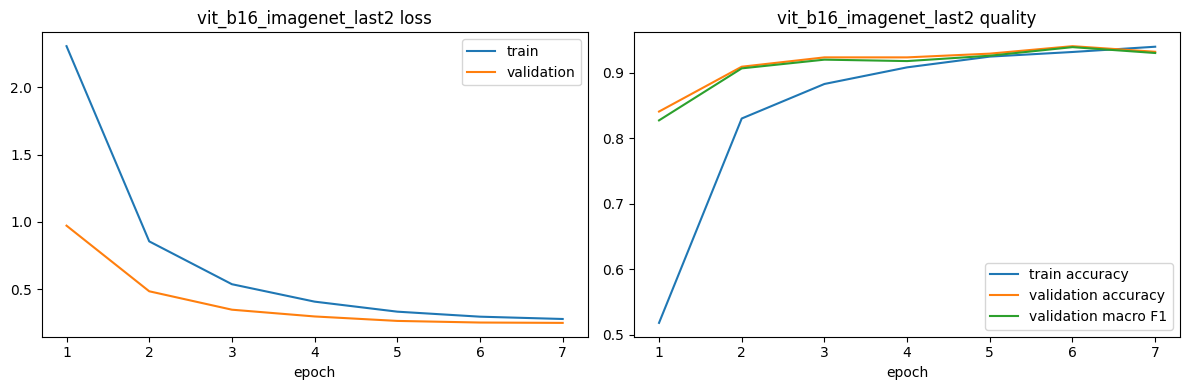

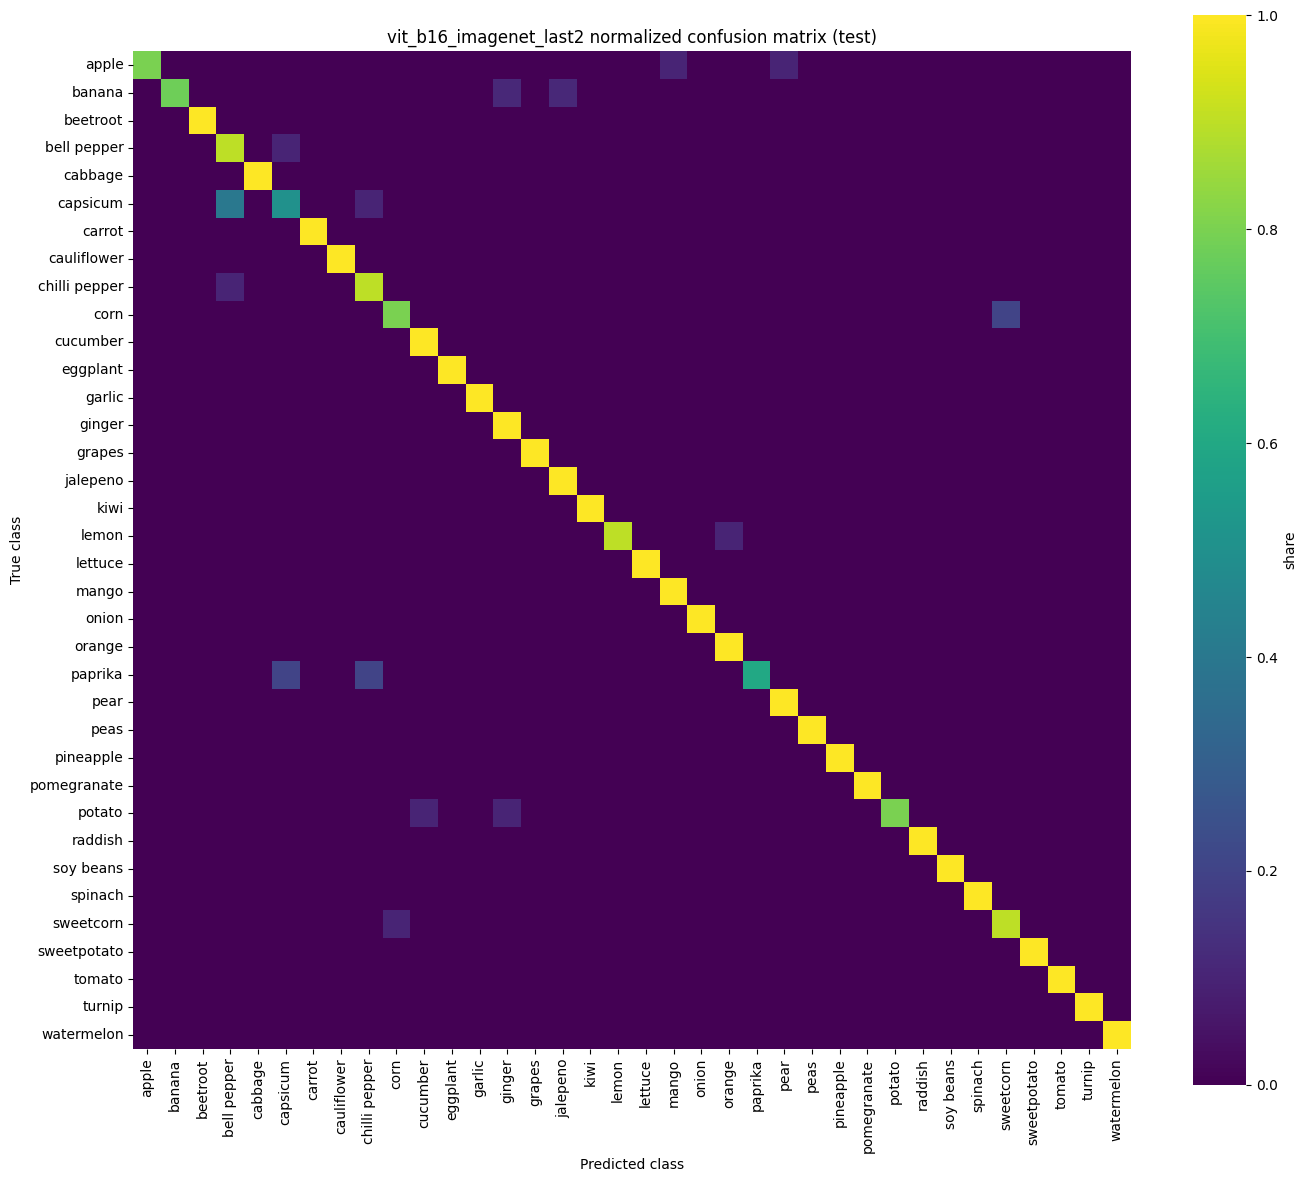

In [6]:
best_record = max(vit_experiment_records, key=lambda item: item["result"]["val"]["macro_f1"])
best_vit_spec = best_record["spec"]
best_torchvision_vit = best_record["result"]

print("Best ViT spec:")
display(pd.DataFrame([best_vit_spec]))
print_report(best_torchvision_vit)
plot_history(best_torchvision_vit)
plot_confusion_matrix(best_torchvision_vit)

## 4. Имплементация алгоритма машинного обучения

Пункты 4.a-4.j: обучаем собственную компактную Vision Transformer с patch embedding, class token, позиционными эмбеддингами, attention-блоками и MLP-head. Собственная модель обучается с нуля, поэтому ожидаемо уступает transfer learning baseline.

Обучаем собственную Vision Transformer в базовом режиме, после чего выводим метрики, графики и confusion matrix.


custom_tiny_vit_plain: training on cuda


epoch 01/5: train_loss=3.1129, train_acc=0.1175, val_loss=2.6589, val_macro_f1=0.1513


epoch 02/5: train_loss=2.6536, train_acc=0.2103, val_loss=2.3129, val_macro_f1=0.2699


epoch 03/5: train_loss=2.4124, train_acc=0.2848, val_loss=2.0205, val_macro_f1=0.3389


epoch 04/5: train_loss=2.2692, train_acc=0.3207, val_loss=1.8869, val_macro_f1=0.3909


epoch 05/5: train_loss=2.1794, train_acc=0.3368, val_loss=1.7042, val_macro_f1=0.4568


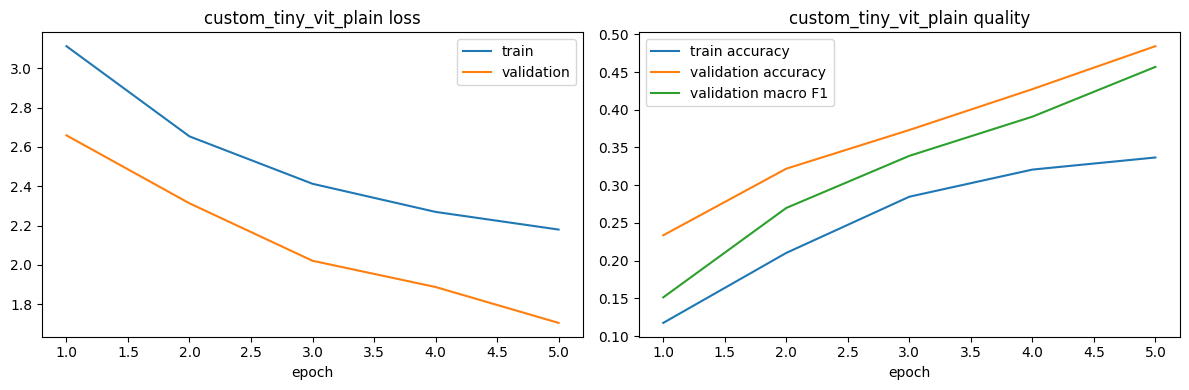

custom_tiny_vit_plain | test classification report
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00        10
       banana       0.40      0.67      0.50         9
     beetroot       0.47      0.80      0.59        10
  bell pepper       0.00      0.00      0.00        10
      cabbage       0.83      0.50      0.62        10
     capsicum       0.32      0.70      0.44        10
       carrot       0.83      1.00      0.91        10
  cauliflower       0.62      0.50      0.56        10
chilli pepper       0.18      0.20      0.19        10
         corn       0.00      0.00      0.00        10
     cucumber       0.40      0.40      0.40        10
     eggplant       0.56      0.50      0.53        10
       garlic       0.73      0.80      0.76        10
       ginger       0.43      0.30      0.35        10
       grapes       0.67      0.60      0.63        10
     jalepeno       0.38      0.30      0.33        10
         kiwi

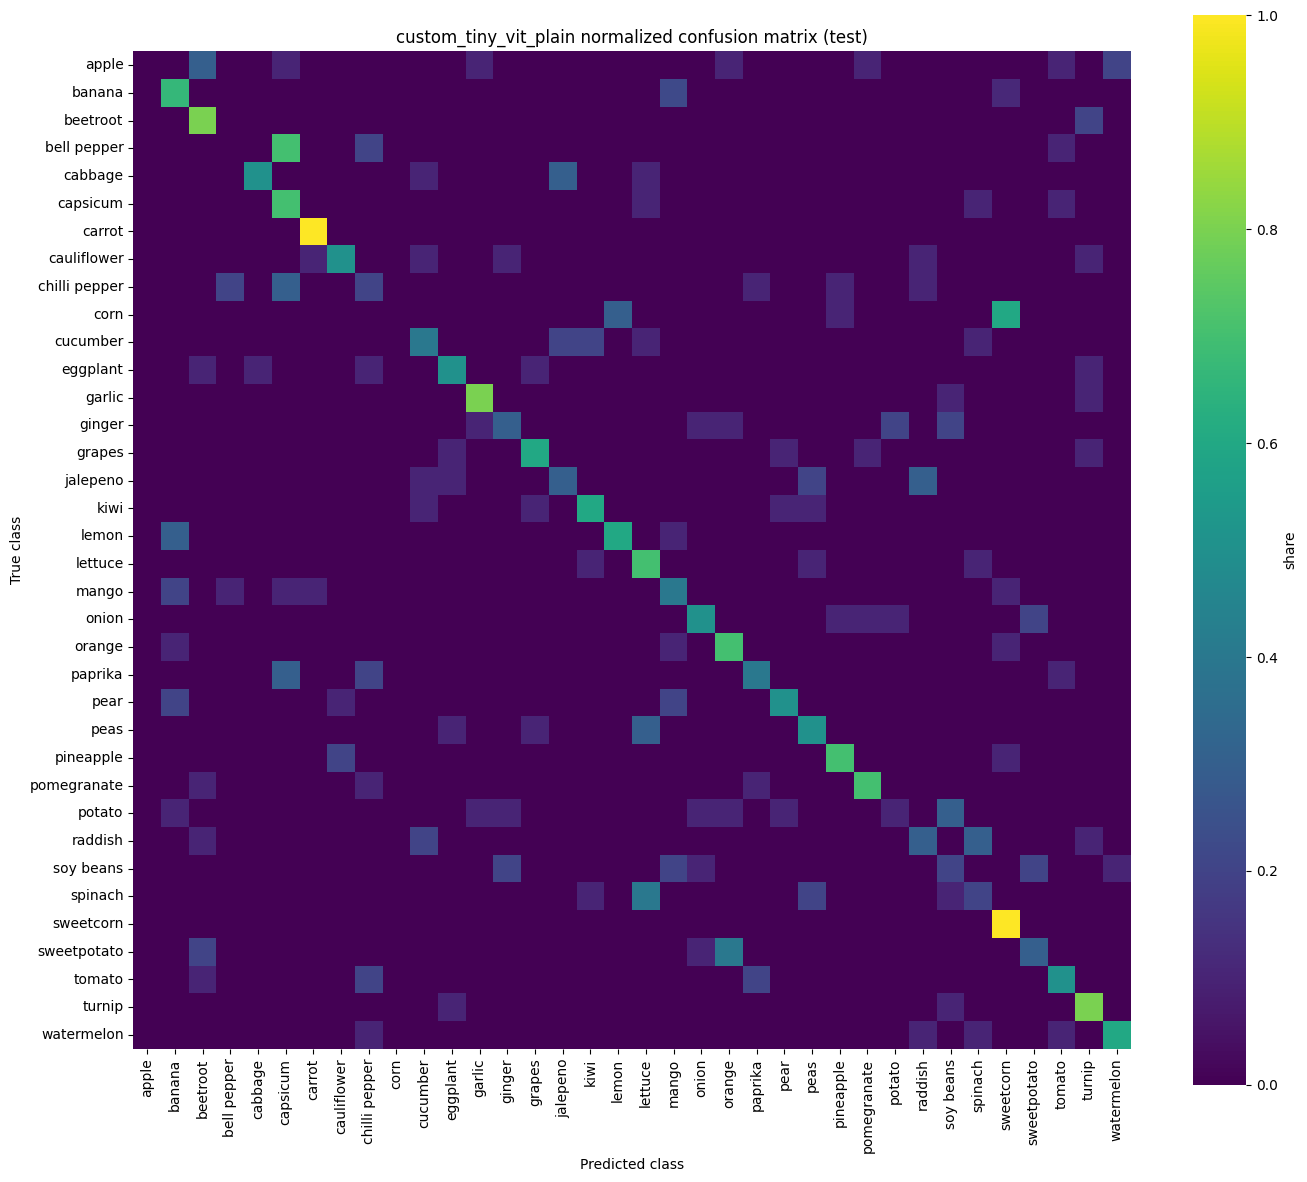

In [7]:
custom_vit_plain = fit_classifier(
    TinyVisionTransformer(
        num_classes=num_classes,
        image_size=IMAGE_SIZE,
        patch_size=16,
        embed_dim=192,
        depth=4,
        num_heads=4,
        dropout=0.10,
    ),
    name="custom_tiny_vit_plain",
    train_loader=plain_loaders.train,
    val_loader=plain_loaders.val,
    test_loader=plain_loaders.test,
    class_names=plain_loaders.class_names,
    config=RunConfig(
        epochs=BASE_EPOCHS,
        learning_rate=3e-4,
        weight_decay=1e-4,
        scheduler="none",
        fast_dev_run=FAST_DEV_RUN,
        seed=SEED,
    ),
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

plot_history(custom_vit_plain)
print_report(custom_vit_plain)
plot_confusion_matrix(custom_vit_plain)

Обучаем собственную Vision Transformer с преобразованиями и scheduler, выбранными на этапе улучшения baseline; learning rate оставляем достаточным для обучения модели с нуля.


custom_tiny_vit_improved: training on cuda


epoch 01/7: train_loss=3.1275, train_acc=0.1169, val_loss=2.6874, val_macro_f1=0.1475


epoch 02/7: train_loss=2.6725, train_acc=0.1987, val_loss=2.2503, val_macro_f1=0.2951


epoch 03/7: train_loss=2.4166, train_acc=0.3002, val_loss=2.0425, val_macro_f1=0.3624


epoch 04/7: train_loss=2.2740, train_acc=0.3252, val_loss=1.8490, val_macro_f1=0.4163


epoch 05/7: train_loss=2.1497, train_acc=0.3605, val_loss=1.7417, val_macro_f1=0.4426


epoch 06/7: train_loss=2.0428, train_acc=0.3978, val_loss=1.6377, val_macro_f1=0.4934


epoch 07/7: train_loss=1.9782, train_acc=0.4250, val_loss=1.6171, val_macro_f1=0.5006


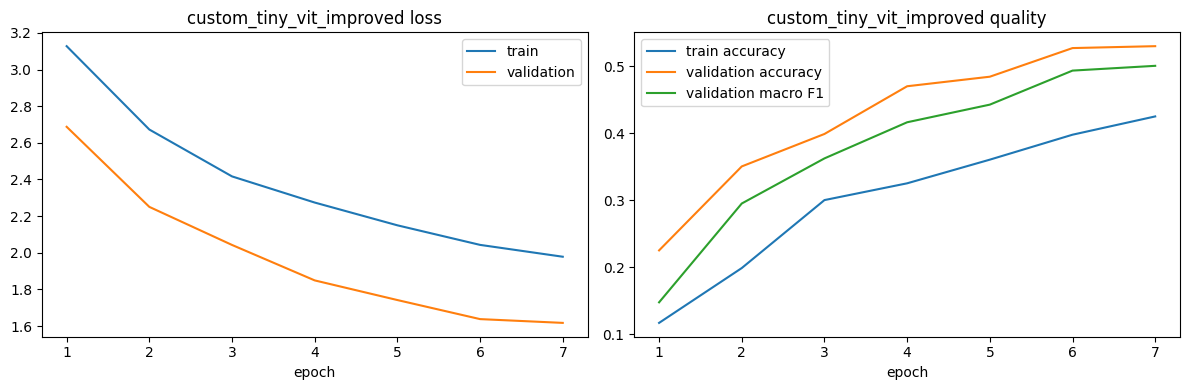

custom_tiny_vit_improved | test classification report
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00        10
       banana       0.40      0.44      0.42         9
     beetroot       0.54      0.70      0.61        10
  bell pepper       0.38      0.30      0.33        10
      cabbage       0.75      0.60      0.67        10
     capsicum       0.40      0.40      0.40        10
       carrot       0.83      1.00      0.91        10
  cauliflower       0.71      0.50      0.59        10
chilli pepper       0.20      0.10      0.13        10
         corn       0.00      0.00      0.00        10
     cucumber       0.23      0.30      0.26        10
     eggplant       0.50      0.60      0.55        10
       garlic       0.67      1.00      0.80        10
       ginger       0.43      0.30      0.35        10
       grapes       0.75      0.60      0.67        10
     jalepeno       0.40      0.20      0.27        10
         k

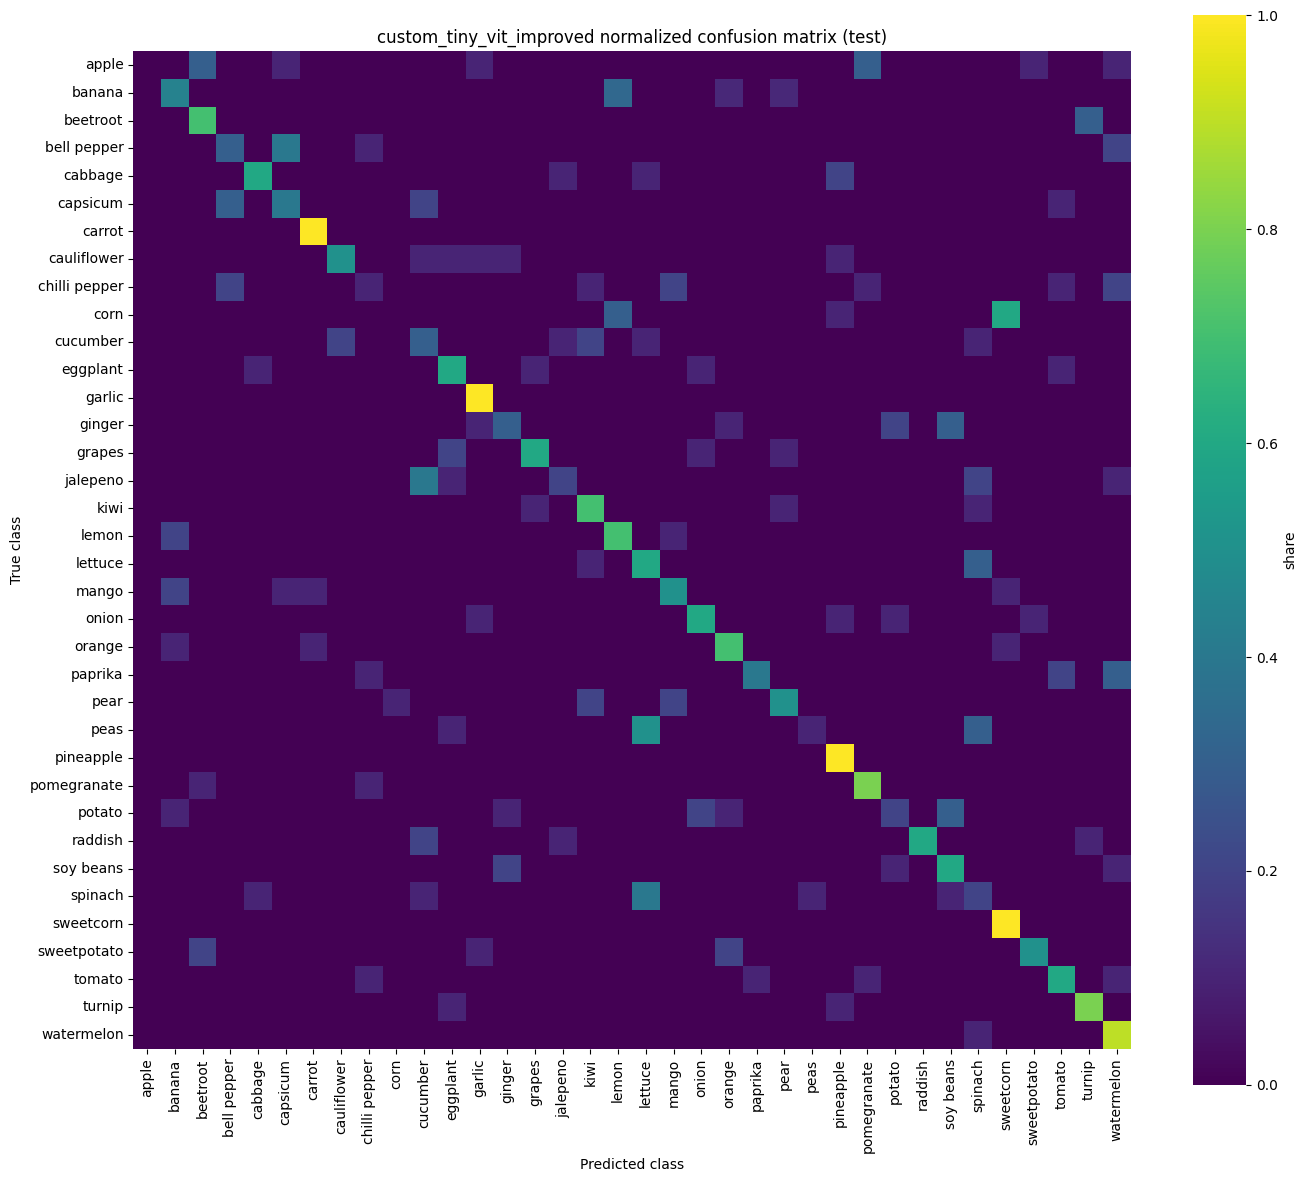

In [8]:
improved_loaders = loaders_for(best_vit_spec["transform_mode"])
custom_improved_lr = max(best_vit_spec["learning_rate"], 3e-4)

custom_vit_improved = fit_classifier(
    TinyVisionTransformer(
        num_classes=num_classes,
        image_size=IMAGE_SIZE,
        patch_size=16,
        embed_dim=192,
        depth=4,
        num_heads=4,
        dropout=0.15,
    ),
    name="custom_tiny_vit_improved",
    train_loader=improved_loaders.train,
    val_loader=improved_loaders.val,
    test_loader=improved_loaders.test,
    class_names=improved_loaders.class_names,
    config=RunConfig(
        epochs=best_vit_spec["epochs"],
        learning_rate=custom_improved_lr,
        weight_decay=best_vit_spec["weight_decay"],
        scheduler=best_vit_spec["scheduler"],
        fast_dev_run=FAST_DEV_RUN,
        seed=SEED,
    ),
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

plot_history(custom_vit_improved)
print_report(custom_vit_improved)
plot_confusion_matrix(custom_vit_improved)

### 4.d-4.j. Сравнение и выводы

Сравниваются baseline, улучшенный `torchvision` baseline, собственная модель и собственная модель с улучшениями.

Формируем финальную таблицу результатов transformer-моделей на test split и краткий вывод по значениям метрик.

In [9]:
vit_final_results = [
    vit_baseline,
    best_torchvision_vit,
    custom_vit_plain,
    custom_vit_improved,
]

display(summarize_results(vit_final_results, split="test"))
print(make_conclusion(vit_final_results, split="test"))

,model,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top3_accuracy
0,torchvision_vit_b16_imagenet_head,5,0.949861,0.954500,0.949691,0.950214,0.950239,0.980501
1,vit_b16_imagenet_last2,6,0.941504,0.947325,0.941049,0.940115,0.940296,0.983287
2,custom_tiny_vit_improved,7,0.529248,0.509621,0.529012,0.499126,0.499343,0.796657
3,custom_tiny_vit_plain,5,0.487465,0.458231,0.487963,0.460451,0.460340,0.782730


Лучший результат по test macro F1 показала модель torchvision_vit_b16_imagenet_head с macro F1=0.9502 и accuracy=0.9499. Разница с наименее успешной конфигурацией в этой таблице составляет 0.4898 по macro F1. Для итогового сравнения важнее macro F1, потому что он одинаково учитывает все 36 классов.
